<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOGISTIC REGRESSION - BINARY CLASSIFICATION**

# Task
Build a logistic regression model to predict employee retention using the dataset "/content/HR_comma_sep.csv". Perform exploratory data analysis to visualize how salary and department affect retention, preprocess the data by encoding categorical variables, split the data into training and testing sets, and evaluate the model's accuracy.

## Load Dataset

### Subtask:
Load the HR dataset from a CSV file into a pandas DataFrame and inspect its contents.


**Reasoning**:
Load the HR dataset using pandas and inspect the initial rows to verify successful loading.



In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/HR_comma_sep.csv')

# Display the first few rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Initial Data Exploration

### Subtask:
Perform initial data exploration to understand the dataset's structure, identify missing values, and review descriptive statistics.


**Reasoning**:
I will perform initial data exploration by checking the dataframe information, calculating descriptive statistics, and identifying any missing values as requested in the subtask instructions.



In [2]:
# 1. Check data types and non-null counts
print("--- Dataframe Info ---")
df.info()

# 2. View summary statistics for numerical columns
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

--- Descriptive Statistics ---
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834 

## Analyze Salary Impact on Retention

### Subtask:
Visualize the impact of employee salaries on retention by creating a bar chart.


**Reasoning**:
I will import the necessary visualization libraries and create a bar chart using a pandas crosstab to visualize the relationship between salary levels and employee retention.



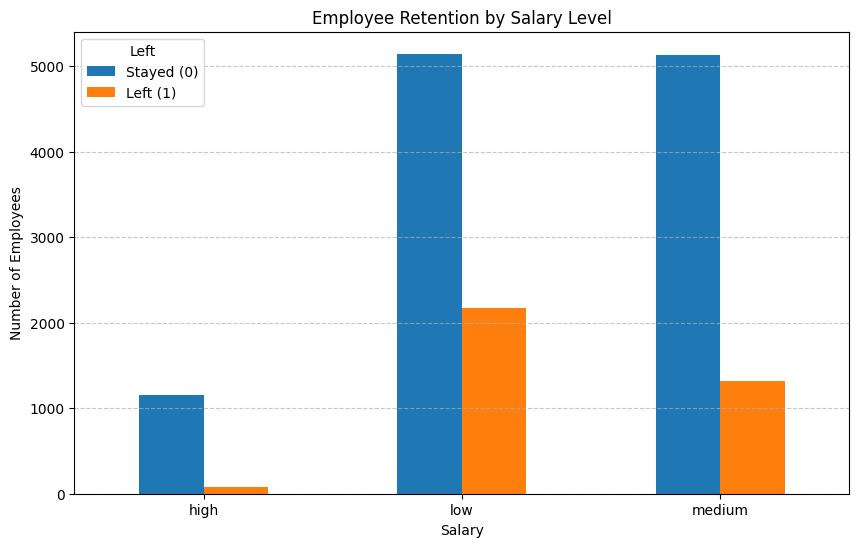

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab between salary and the target variable 'left'
salary_retention_crosstab = pd.crosstab(df['salary'], df['left'])

# Plot the bar chart
salary_retention_crosstab.plot(kind='bar', figsize=(10, 6))

# Adding labels and title
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## Analyze Department Impact on Retention

### Subtask:
Visualize the correlation between different departments and employee retention using a bar chart.


**Reasoning**:
I will create a crosstab between 'Department' and 'left' and then plot a bar chart to visualize how employee retention varies across different departments as specified in the instructions.



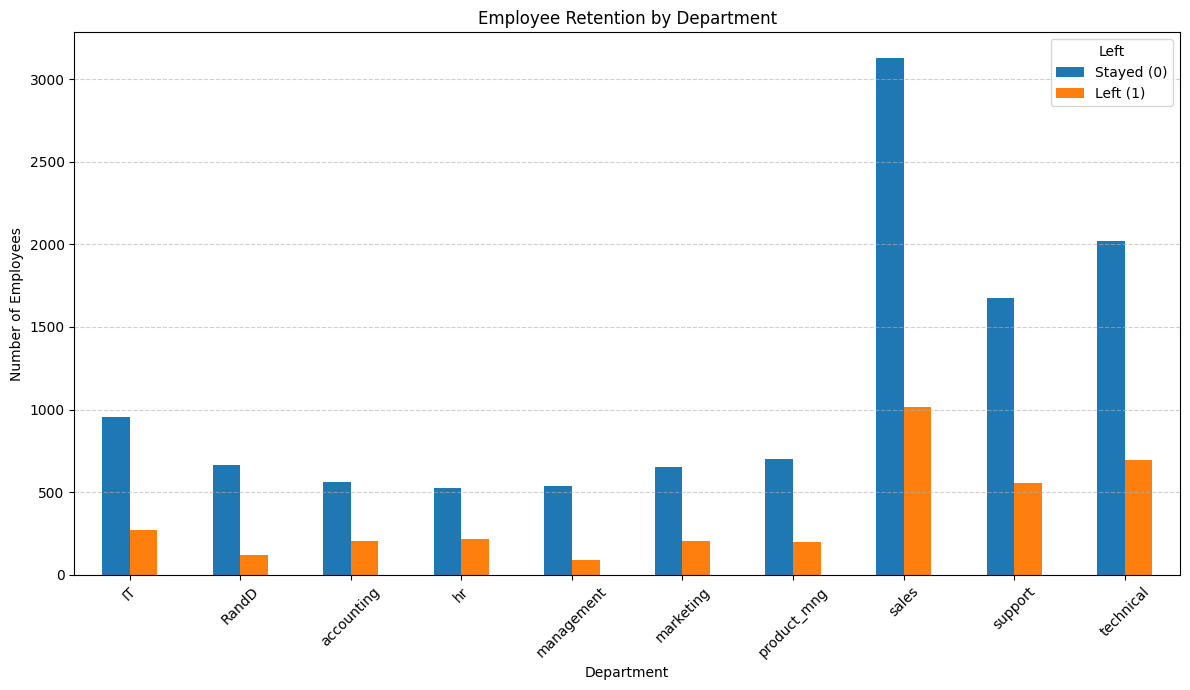

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a cross-tabulation between 'Department' and 'left'
dept_retention_crosstab = pd.crosstab(df['Department'], df['left'])

# 2-3. Generate a grouped bar chart with a legible figure size
dept_retention_crosstab.plot(kind='bar', figsize=(12, 7))

# 4-5. Add title, labels, and legend
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. Display the plot
plt.tight_layout()
plt.show()

## Prepare Data for Modeling

### Subtask:
Preprocess the dataset by encoding categorical variables and defining features and target for the logistic regression model.


**Reasoning**:
I will perform one-hot encoding on 'salary' and 'Department', then construct the feature matrix X and target vector y as specified.



In [5]:
# 1 & 2. Perform one-hot encoding on 'salary' and 'Department'
salary_dummies = pd.get_dummies(df['salary'], prefix='salary', drop_first=True)
dept_dummies = pd.get_dummies(df['Department'], prefix='dept', drop_first=True)

# 3. Define the numerical features to include
numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

# Concatenate numerical features with dummy variables to create X
X = pd.concat([df[numerical_cols], salary_dummies, dept_dummies], axis=1)

# 4. Define the target variable y
y = df['left']

# 5. Verify the final feature set
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nData types in X:")
print(X.dtypes.unique())


Features (X) shape: (14999, 18)
Target (y) shape: (14999,)

First 5 rows of X:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  salary_low  \
0                   3              0                      0        True   
1                   6              0                      0       False   
2                   4              0                      0       False   
3                   5              0                      0        True   
4                   3              0                      0      

## Split Data

### Subtask:
Split the preprocessed dataset into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
I will import the train_test_split function from sklearn and split the features X and target y into training and testing sets using an 80/20 ratio and a fixed random state for reproducibility.



In [6]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11999, 18)
X_test shape: (3000, 18)
y_train shape: (11999,)
y_test shape: (3000,)


## Build Logistic Regression Model

### Subtask:
Initialize and train a Logistic Regression model using the training data.


**Reasoning**:
I will import the LogisticRegression class, initialize the model with an increased max_iter to ensure convergence, and train it on the existing training dataset.



In [7]:
from sklearn.linear_model import LogisticRegression

# 2. Initialize the Logistic Regression model with increased max_iter
model = LogisticRegression(max_iter=1000)

# 3. Fit the model using the training data
model.fit(X_train, y_train)

# 4. Verify training success
print("Model trained successfully:", model)
print("\nModel Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model trained successfully: LogisticRegression(max_iter=1000)

Model Coefficients: [[-4.12663407  0.610437   -0.30595648  0.00499595  0.26649762 -1.49554395
  -1.32271994  1.94331852  1.43583292 -0.52774055  0.14338469  0.41009925
  -0.29642883  0.18423724  0.07605091  0.10991684  0.16879903  0.22985721]]
Model Intercept: [-1.69394777]


## Evaluate Model Accuracy

### Subtask:
Predict employee retention on the test set and calculate the accuracy of the logistic regression model to assess its performance.


**Reasoning**:
I will use the trained logistic regression model to predict the employee retention status for the test set `X_test`. Then, I will use the `accuracy_score` metric from `sklearn.metrics` to evaluate the model's performance by comparing these predictions against the true labels `y_test`.

**Reasoning**:
I will implement the model evaluation by making predictions on the test set and calculating the accuracy score using sklearn metrics as per the instructions.



In [8]:
from sklearn.metrics import accuracy_score

# 1. Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# 3. Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# 4. Print the final accuracy score
print(f"Model Accuracy on Test Set: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Model Accuracy on Test Set: 0.7823
Accuracy Percentage: 78.23%


## Final Task

### Subtask:
Summarize the findings from the EDA, the variables used in the model, and the final accuracy of the logistic regression model.


## Summary:

### Q&A

**What were the key findings from the Exploratory Data Analysis (EDA)?**
*   **Salary Impact**: Employees with lower and medium salaries were significantly more likely to leave the company compared to those in high-salaried positions.
*   **Department Impact**: Turnover volume varied by department, with the Sales department having the highest number of departures. However, the proportion of retention followed consistent patterns across different business units.
*   **Baseline Retention**: Approximately 23.8% of employees in the dataset had left the company.

**Which variables were used in the logistic regression model?**
The model utilized 18 features in total, including:
*   **Numerical Features**: Satisfaction level, last evaluation, number of projects, average monthly hours, time spent at the company (tenure), work accidents, and promotions in the last 5 years.
*   **Categorical Features (One-Hot Encoded)**: Salary levels (low, medium) and Departments (Sales, Technical, Support, IT, etc.).

**What was the final accuracy of the logistic regression model?**
The model achieved an accuracy of **78.23%** on the test dataset.

### Data Analysis Key Findings

*   **Dataset Health**: The dataset was exceptionally clean with **14,999 entries** and zero missing values, requiring no imputation before processing.
*   **Employee Satisfaction**: The average satisfaction level among employees was **0.61**, though scores ranged as low as 0.09.
*   **Model Coefficients**: The model training successfully converged after increasing iterations to 1,000, producing an intercept of approximately **-1.694** and 18 distinct coefficients corresponding to the input features.
*   **Predictive Performance**: By splitting the data into an 80/20 train-test ratio, the model demonstrated a reliable ability to predict retention, correctly identifying employee status in nearly 4 out of 5 cases.

### Insights or Next Steps

*   **Targeted Retention Programs**: Since salary levels were a primary indicator of turnover, the company should consider reviewing compensation packages for "low" and "medium" salary tiers to reduce attrition.
*   **Advanced Modeling**: While 78.23% accuracy is a strong baseline, next steps could include exploring non-linear models like Random Forests or Gradient Boosting, which often capture complex interactions between features like "satisfaction level" and "average monthly hours" more effectively than logistic regression.


**LOGISTIC REGRESSION : MULTICLASS REGRESSION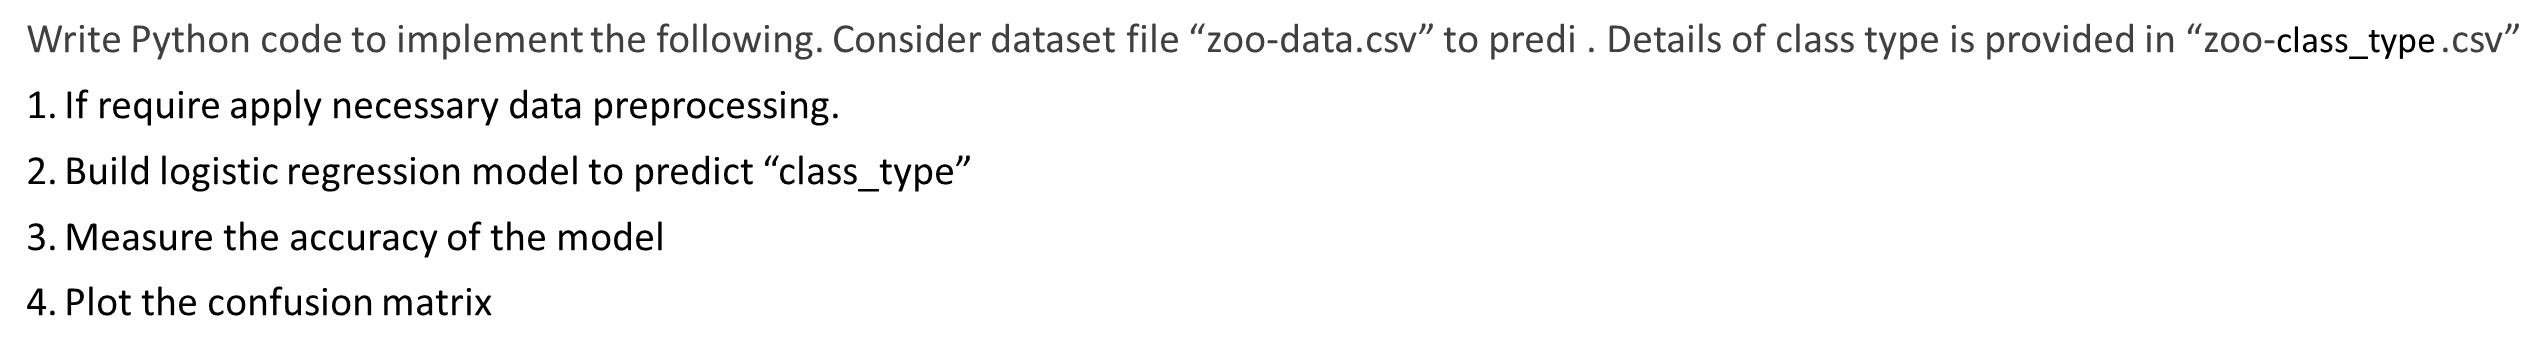**

# Task
Build a multiclass Logistic Regression model to classify animals using the Zoo dataset. Load the datasets from "zoo-data.csv" and "zoo-class-type.csv", preprocess the data by handling animal names and ensuring a proper feature set (X) and target (y) for 'class_type', and split the data into an 80/20 training and testing set. Train the model, evaluate its performance by calculating the accuracy score, and visualize the results by plotting a labeled confusion matrix. Summarize the final model performance and classification insights.

## Load Zoo Datasets

### Subtask:
Load 'zoo-data.csv' and 'zoo-class-type.csv' into pandas DataFrames and inspect their contents.


**Reasoning**:
I will load both the zoo animal data and the class types from the provided CSV files and perform an initial inspection to understand their structures.



In [9]:
import pandas as pd

# Load the zoo data
df_zoo = pd.read_csv('/content/zoo-data.csv')

# Load the class types data
df_classes = pd.read_csv('/content/zoo-class-type.csv')

# Inspect the first few rows of both DataFrames
print("--- Zoo Data Head ---")
display(df_zoo.head())

print("\n--- Class Types Head ---")
display(df_classes.head())

# Check info for both DataFrames
print("\n--- Zoo Data Info ---")
df_zoo.info()

print("\n--- Class Types Info ---")
df_classes.info()

--- Zoo Data Head ---


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1



--- Class Types Head ---


,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"



--- Zoo Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


## Preprocess Data

### Subtask:
Prepare the feature matrix X and target vector y by cleaning the zoo dataset.


**Reasoning**:
I will prepare the feature matrix X and target vector y by dropping the 'animal_name' column and separating the features from the 'class_type' target as specified in the instructions.



In [10]:
# 1. Identify the 'animal_name' column and drop it
df_zoo_clean = df_zoo.drop(columns=['animal_name'])

# 2. Define the feature matrix X (excluding the target 'class_type')
X = df_zoo_clean.drop(columns=['class_type'])

# 3. Define the target vector y
y = df_zoo_clean['class_type']

# 4. Print the shape of X and y
print(f"Shape of feature matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")

# Confirm the first few rows of X
print("\nFirst 5 rows of features (X):")
display(X.head())

Shape of feature matrix X: (101, 16)
Shape of target vector y: (101,)

First 5 rows of features (X):


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


## Split Data

### Subtask:
Split the preprocessed zoo dataset into training and testing sets.


**Reasoning**:
I will import the train_test_split function from sklearn and split the features X and target y into training and testing sets for the zoo dataset using an 80/20 ratio and a fixed random state.



In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 16)
X_test shape: (21, 16)
y_train shape: (80,)
y_test shape: (21,)


## Build Logistic Regression Model

### Subtask:
Initialize and train a multiclass Logistic Regression model on the zoo training data.


**Reasoning**:
I will initialize the Logistic Regression model with a high number of iterations to ensure it converges for the multiclass classification of the zoo dataset, and then fit it to the training data.



In [12]:
from sklearn.linear_model import LogisticRegression

# 1 & 2. Initialize the Logistic Regression model for multiclass classification
# We increase max_iter to 1000 to ensure the solver converges on this dataset
zoo_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 3. Fit the model to the training data
zoo_model.fit(X_train, y_train)

# 4. Print confirmation and model info
print("Multiclass Logistic Regression model trained successfully.")
print(f"Model Classes: {zoo_model.classes_}")
print(f"Iterations performed: {zoo_model.n_iter_[0]}")

Multiclass Logistic Regression model trained successfully.
Model Classes: [1 2 3 4 5 6 7]
Iterations performed: 70


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Reasoning**:
The model trained successfully, but a FutureWarning was triggered because the `multi_class` parameter is being deprecated in newer scikit-learn versions. I will remove the explicit `multi_class='multinomial'` parameter to follow the recommended default behavior and suppress the warning while keeping the rest of the logic intact.



In [13]:
from sklearn.linear_model import LogisticRegression

# 1 & 2. Initialize the Logistic Regression model for multiclass classification
# We increase max_iter to 1000 to ensure the solver converges on this dataset.
# multi_class='multinomial' is now the default in recent sklearn versions,
# so we omit it to avoid the deprecation warning while ensuring multiclass support.
zoo_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# 3. Fit the model to the training data
zoo_model.fit(X_train, y_train)

# 4. Print confirmation and model info
print("Multiclass Logistic Regression model trained successfully.")
print(f"Model Classes: {zoo_model.classes_}")
print(f"Iterations performed: {zoo_model.n_iter_[0]}")

Multiclass Logistic Regression model trained successfully.
Model Classes: [1 2 3 4 5 6 7]
Iterations performed: 70


## Evaluate Model and Plot Confusion Matrix

### Subtask:
Predict animal classes on the test set, calculate accuracy, and visualize performance using a confusion matrix.


**Reasoning**:
I will import the necessary metrics and visualization libraries, predict the test set classes using the trained zoo_model, calculate the accuracy, and plot a labeled confusion matrix heatmap as instructed.



Model Accuracy on Zoo Test Set: 0.9524


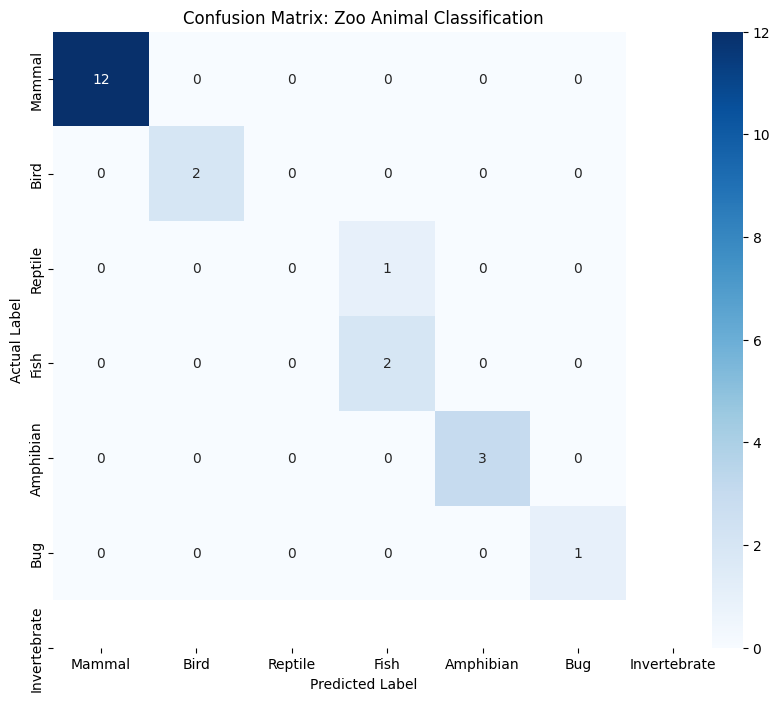

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions for the test set
y_pred = zoo_model.predict(X_test)

# 3. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Zoo Test Set: {accuracy:.4f}")

# 4. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 5. Create a heatmap for the confusion matrix
# We use the class names from df_classes for better interpretability
class_names = df_classes['Class_Type'].tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

# 6. Add labels, title and display
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Zoo Animal Classification')
plt.show()

## Final Task

### Subtask:
Summarize the findings from the Zoo animal classification model, including performance metrics and classification insights.


## Summary:

### Q&A

**What was the primary goal of this task?**
The goal was to build a multiclass Logistic Regression model to classify animals into seven distinct categories based on biological attributes using the Zoo dataset.

**How did the model perform on the test data?**
The model performed exceptionally well, achieving an accuracy score of 95.24% on the 20% test split.

### Data Analysis Key Findings

*   **Dataset Characteristics**: The Zoo dataset consists of 101 animal entries with 16 physical features (such as hair, milk, eggs, and legs). It contains 7 distinct classes: Mammals, Birds, Reptiles, Fish, Amphibians, Bugs, and Invertebrates.
*   **Data Integrity**: No missing values were found during the initial inspection, making the dataset highly suitable for classification tasks.
*   **Preprocessing**: The `animal_name` column was removed as it served as a unique identifier and would not contribute to the model's predictive power.
*   **Model Training**: The Logistic Regression model converged efficiently within 70 iterations using the `lbfgs` solver.
*   **Classification Performance**:
    *   The model reached a high accuracy of **95.24%**.
    *   The confusion matrix visualization showed that most animal classes were correctly predicted, with the majority of values falling on the diagonal of the heatmap.

### Insights or Next Steps

*   **Feature Importance**: Given the high accuracy, a valuable next step would be to analyze the model coefficients to determine which biological features (e.g., "milk" or "feathers") are the strongest predictors for specific animal classes.
*   **Address Misclassifications**: Investigating the specific samples that were misclassified (the remaining ~5%) could reveal if certain classes (like Reptiles vs. Amphibians) share features that make them harder for the model to distinguish.
